In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
df= pd.read_excel("/content/drive/MyDrive/StockPricePrediction.xlsx")
df['Date'] = pd.to_datetime(df['Date'])
print (df)

          Date  Accor S.A.  Thales S.A.   Michelin  Pernod Ricard S.A.  \
0   2023-01-19   28.879999   118.000000  28.860001          192.300003   
1   2023-01-20   29.120001   120.250000  28.290001          191.500000   
2   2023-01-23   29.139999   121.500000  28.830000          195.050003   
3   2023-01-24   29.420000   122.900002  28.855000          193.750000   
4   2023-01-25   29.459999   121.199997  28.870001          193.149994   
..         ...         ...          ...        ...                 ...   
505 2025-01-13   46.820000   144.100006  30.900000          104.750000   
506 2025-01-14   47.509998   145.250000  31.740000          103.949997   
507 2025-01-15   47.820000   145.350006  32.689999          102.800003   
508 2025-01-16   47.650002   147.149994  32.490002          104.400002   
509 2025-01-17   48.060001   148.500000  32.910000          107.400002   

     Renault S.A.  
0       36.500000  
1       36.480000  
2       37.290001  
3       37.334999  
4       37.

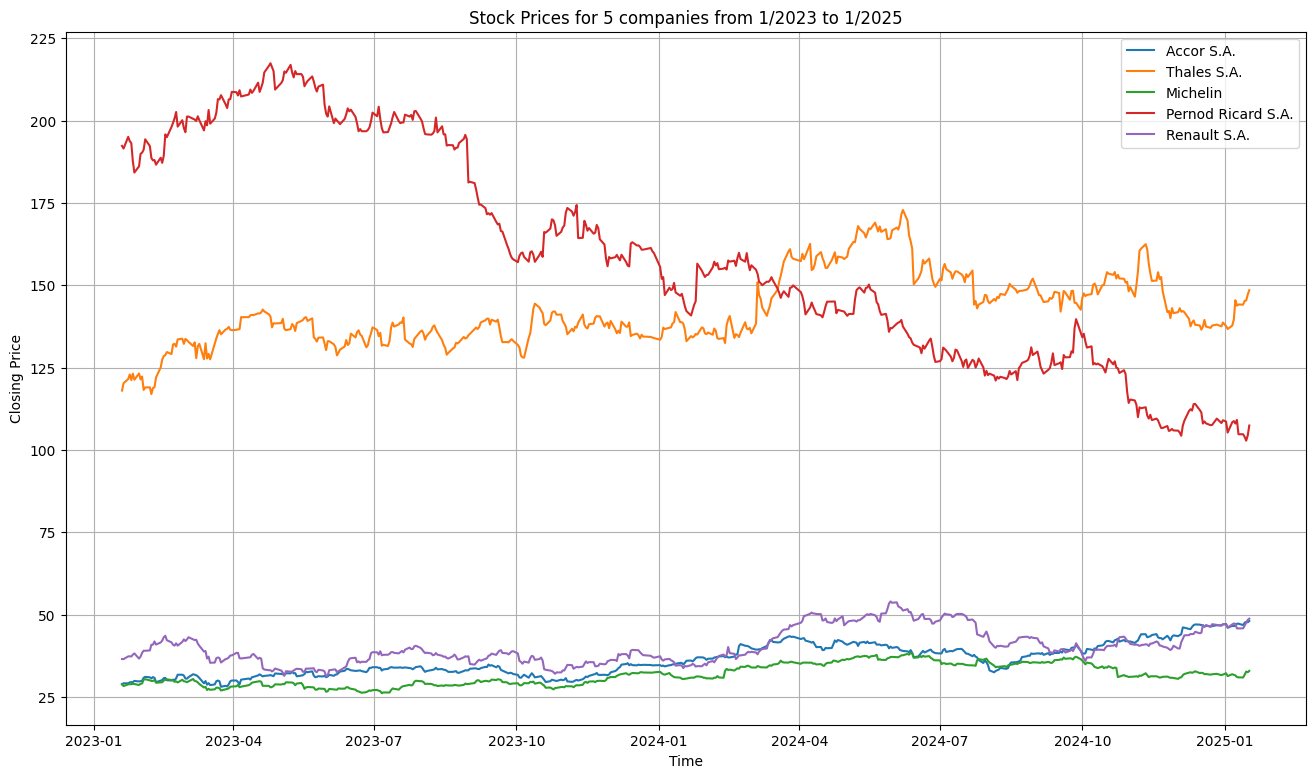

In [ ]:
plt.figure(figsize=(16,9))
for company in df.columns[1:]:
    plt.plot(df['Date'], df[company], label=company)
plt.legend()
plt.title('Stock Prices for 5 companies from 1/2023 to 1/2025')
plt.ylabel('Closing Price')
plt.xlabel('Time')
plt.grid(True)
plt.show()

*1*. Thales S.A.

In [3]:
columns_thales = [df.columns[0], df.columns[2]]
df_thales = df[columns_thales]
print(df_thales)

          Date  Thales S.A.
0   2023-01-19   118.000000
1   2023-01-20   120.250000
2   2023-01-23   121.500000
3   2023-01-24   122.900002
4   2023-01-25   121.199997
..         ...          ...
505 2025-01-13   144.100006
506 2025-01-14   145.250000
507 2025-01-15   145.350006
508 2025-01-16   147.149994
509 2025-01-17   148.500000

[510 rows x 2 columns]


In [4]:
data_train = df_thales.iloc[0:435,:]
training_set = data_train.iloc[:, 1:2].values
sc = MinMaxScaler(feature_range = (0, 1))
training_set_scaled = sc.fit_transform(training_set)
X_train = []
y_train = []
no_of_sample = len(training_set)
for i in range(40, no_of_sample):
    X_train.append(training_set_scaled[i-40:i, 0])
    y_train.append(training_set_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [13]:
regressor = Sequential()
regressor.add(LSTM(units = 300, return_sequences = True, input_shape = (X_train.shape[1], 1)))
regressor.add(Dropout(0.01))
regressor.add(LSTM(units = 200, activation = 'tanh', return_sequences = True))
regressor.add(Dropout(0.01))
regressor.add(LSTM(units = 50, activation = 'tanh'))
regressor.add(Dropout(0.0))
regressor.add(Dense(units = 1))
regressor.compile(optimizer=Adam(learning_rate=0.001), loss = 'mean_squared_error')
history= regressor.fit(X_train, y_train, epochs = 100, batch_size = 32, validation_split=0.15)
regressor.save("predictionmodel.h5")

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 224ms/step - loss: 0.1105 - val_loss: 0.0107
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 180ms/step - loss: 0.0126 - val_loss: 0.0027
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 254ms/step - loss: 0.0089 - val_loss: 0.0027
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 183ms/step - loss: 0.0065 - val_loss: 0.0027
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 183ms/step - loss: 0.0062 - val_loss: 0.0030
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 185ms/step - loss: 0.0055 - val_loss: 0.0031
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 259ms/step - loss: 0.0056 - val_loss: 0.0039
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 178ms/step - loss: 0.0052 - val_loss: 0.0034
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 179ms/step - loss: 0.0047 - val_loss: 0.0028
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 182ms/step - loss: 0.0053 - val_loss: 0.0033
Epoch 11/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 262ms/step - loss: 0.0048 - val_loss: 0.0032
Epoch 12/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 179ms/step

In [14]:
data_test = df_thales.iloc[435:,:]
test_set = data_test.iloc[:, 1:2].values
dataset_total= pd.concat((data_train['Thales S.A.'], data_test['Thales S.A.']), axis = 0)
inputs = dataset_total[len(dataset_total) - len(data_test) - 40:].values
inputs = inputs.reshape(-1,1)
inputs = sc.transform(inputs)
X_test = []
no_of_sample = len(inputs)
for i in range(40, no_of_sample):
    X_test.append(inputs[i-40:i, 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price= sc.inverse_transform(predicted_stock_price)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step


In [15]:
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(test_set, predicted_stock_price))
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 2.1581402697616134


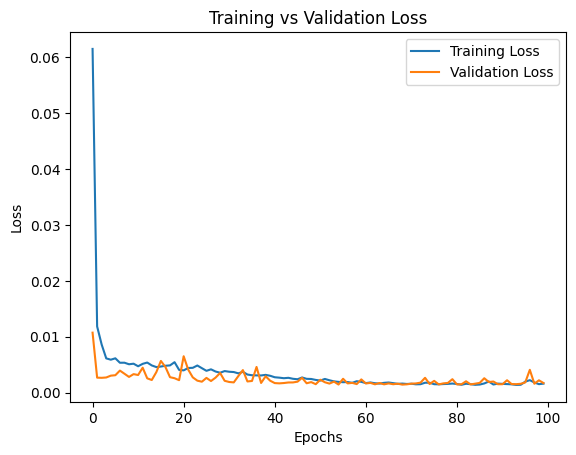

In [16]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.show()

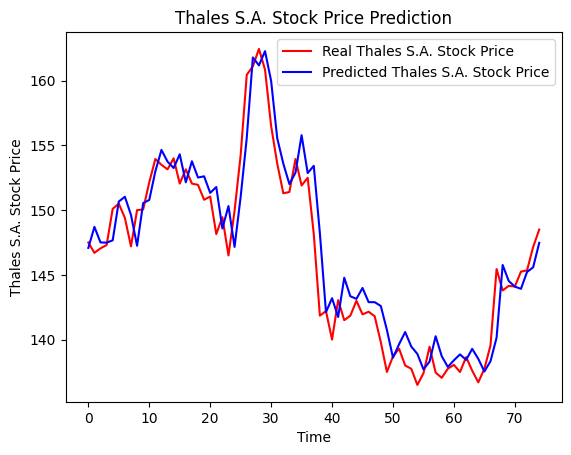

In [17]:
plt.plot(test_set, color = 'red', label = 'Real Thales S.A. Stock Price')
plt.plot(predicted_stock_price, color = 'blue', label = 'Predicted Thales S.A. Stock Price')
plt.title('Thales S.A. Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Thales S.A. Stock Price')
plt.legend()
plt.show()

In [18]:
dataset_test = df_thales['Thales S.A.'][-40:].to_numpy()
inputs = dataset_test.reshape(-1, 1)
inputs = sc.transform(inputs)

In [19]:
predictions = []
for i in range(30):
    X_test = inputs[-40:].reshape(1, -1, 1)
    predicted_stock_price = regressor.predict(X_test)
    predicted_stock_price = sc.inverse_transform(predicted_stock_price)
    inputs = np.append(inputs, sc.transform(predicted_stock_price.reshape(-1, 1)), axis=0)
    predictions.append(predicted_stock_price[0][0])
    days = [f'Day {i+1}' for i in range(30)]
predicted_table = pd.DataFrame({
    'Day': days,
    'Predicted Price': predictions })
print(predicted_table)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━